# ============================================================
# **BANK CUSTOMER CHURN PREDICTION (OPTIMIZED PRODUCTION PIPELINE)**
# ============================================================


# **Project Overview & Objectives**

* **Objective**: Predict whether a bank customer will churn (cancel their account / exit the bank).
* **Model Type**: Binary Classification ($0 = \text{Retained / Stayed}$, $1 = \text{Churned / Exited}$).
* **Dataset**: `Churn_Modelling.csv` (10,000 customer profiles with demographic, financial, and product features).
* **Production Optimization Enhancements**:
  1. **Feature Importance Analysis**: Quantify predictive drivers using model-native importance (tree-based Gini/Gain or Logistic Regression coefficients).
  2. **Permutation Importance Analysis**: Measure holdout Permutation Importance on the test set with leakage-free feature name extraction.
  3. **SHAP Explainability**: Compute SHAP values with the appropriate explainer (TreeExplainer or LinearExplainer) for global and local interpretability.
  4. **Probability Threshold Optimization**: Sweep decision thresholds to maximize Recall while controlling Precision degradation for asymmetric churn misclassification costs.
  5. **Bayesian Hyperparameter Optimization via Optuna**: Replace grid search with Optuna TPE sampling, Stratified 5-Fold Cross-Validation, and visual convergence diagnostics.
  6. **Model Benchmarking**: Compare Logistic Regression, Random Forest, and XGBoost with automatic best-model selection.
  7. **Advanced Imbalance Handling (SMOTETomek)**: Combine synthetic oversampling (SMOTE) with Tomek Link boundary cleaning inside leak-free cross-validation folds.
  8. **Automated Feature Selection (RFECV)**: Implement Recursive Feature Elimination with Cross-Validation to prune non-informative features without data leakage.


# 📊 Dataset Description: Churn Modelling

The **Churn Modelling** dataset contains 10,000 bank customer profiles described by 14 initial features. The target column to predict is `Churn` (originally named `Exited`).

| **Variable** | **Data Type** | **Description** |
|---|---|---|
| `RowNumber` | Numerical (int) | Sequential row index (system identifier, excluded from model) |
| `CustomerId` | Numerical (int) | Unique customer identifier (excluded from model) |
| `Surname` | Text (string) | Customer surname (excluded from model) |
| `CreditScore` | Numerical (int) | Customer credit score |
| `Geography` | Categorical (string) | Country of residence (`France`, `Spain`, `Germany`) |
| `Gender` | Categorical (string) | Customer gender (`Male` / `Female`) |
| `Age` | Numerical (int) | Customer age in years |
| `Tenure` | Numerical (int) | Number of years the customer has been with the bank |
| `Balance` | Numerical (float) | Bank account balance |
| `NumOfProducts` | Numerical (int) | Number of bank products owned by the customer |
| `HasCrCard` | Binary (int) | Credit card ownership flag ($1 = \text{Yes}$, $0 = \text{No}$) |
| `IsActiveMember` | Binary (int) | Customer activity status with the bank ($1 = \text{Active}$, $0 = \text{Inactive}$) |
| `EstimatedSalary` | Numerical (float) | Estimated customer annual salary |
| `Churn` | Binary (int) | **Target Variable**: $1 = \text{Customer churned}$, $0 = \text{Customer retained}$ |

> 💡 The dataset combines demographic, financial, and behavioral attributes. `Churn` is the target variable for binary classification.


# **1. Exploratory Data Analysis (EDA)**

* **Purpose**: Inspect dataset structure, distributions, missing values, outliers, and feature relationships with customer churn.
* **Why Important**: Understanding data distributions and key predictive signals prevents erroneous assumptions and guides pipeline construction, feature engineering, and model selection.
* **Expected Outcome**: Clear baseline insights into feature types, target class imbalance, statistical significance, and data cleaning requirements.


## **1.1 Import Libraries & Configure Environment**


In [ ]:
# Install required libraries if running in Colab or fresh environment
for pkg in ['feature-engine', 'optuna', 'imbalanced-learn', 'shap']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
%matplotlib inline
import scipy.stats as stats
from scipy.stats import chi2_contingency
import optuna
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFECV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from feature_engine.outliers import Winsorizer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

import time

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("All production ML libraries imported successfully! ✅")


In [ ]:
from matplotlib import rcParams

rcParams['figure.figsize'] = (12, 6)
rcParams['axes.facecolor'] = '#f8f9fa'
rcParams['figure.facecolor'] = 'white'
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.3
rcParams['grid.color'] = '#cccccc'
rcParams['axes.edgecolor'] = '#333333'
rcParams['axes.linewidth'] = 1.2
rcParams['font.family'] = 'sans-serif'
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 14
rcParams['axes.titleweight'] = 'bold'
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10
rcParams['legend.framealpha'] = 0.9

COLORS = ['#7B2CBF', '#9D4EDD', '#C77DFF', '#E0AAFF', '#5A189A', '#240046']

print("=" * 70)
print("  VISUALIZATION THEME CONFIGURED ✅")
print("=" * 70)


  VISUALIZATION THEME CONFIGURED ✅


## **1.2 Data Loading & Initial Inspection**


In [ ]:
df = pd.read_csv("Churn_Modelling.csv")
# Rename 'Exited' to 'Churn' for clarity
df.rename(columns={'Exited': 'Churn'}, inplace=True)
print("Data loaded successfully ✅")


Data loaded successfully ✅


In [ ]:
# Dataset dimensions
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset Shape: 10000 rows, 14 columns


In [ ]:
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Remove non-predictive identifier columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)
print(f"Removed identifier columns: RowNumber, CustomerId, Surname. Remaining columns: {df.shape[1]}")


Removed identifier columns: RowNumber, CustomerId, Surname. Remaining columns: 11


In [ ]:
# Inspect unique values per feature
for col in df.columns:
    print(f"Column: {col} | Unique Count: {df[col].nunique()}")
    print(f"Sample Values: {df[col].unique()[:10]}")
    print("*" * 65)


Column: CreditScore | Unique Count: 460
Sample Values: [619 608 502 699 850 645 822 376 501 684]
*****************************************************************
Column: Geography | Unique Count: 3
Sample Values: ['France' 'Spain' 'Germany']
*****************************************************************
Column: Gender | Unique Count: 2
Sample Values: ['Female' 'Male']
*****************************************************************
Column: Age | Unique Count: 70
Sample Values: [42 41 39 43 44 50 29 27 31 24]
*****************************************************************
Column: Tenure | Unique Count: 11
Sample Values: [ 2  1  8  7  4  6  3 10  5  9]
*****************************************************************
Column: Balance | Unique Count: 6382
Sample Values: [     0.    83807.86 159660.8  125510.82 113755.78 115046.74 142051.07
 134603.88 102016.72 143129.41]
*****************************************************************
Column: NumOfProducts | Unique Count: 4
Sample 

In [ ]:
# Quantitatives variables
quant_var = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
# Qualitatives variables
quali_var = ["IsActiveMember", "Geography", "Gender", "HasCrCard"]
print(f"Quantitative variables ({len(quant_var)}): {quant_var}")
print(f"Qualitative variables ({len(quali_var)}): {quali_var}")


Quantitative variables (6): ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
Qualitative variables (4): ['IsActiveMember', 'Geography', 'Gender', 'HasCrCard']


In [ ]:
print("=== DataFrame Information ===")
df.info()


=== DataFrame Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Churn            10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [ ]:
print("\n=== Quantitative Feature Statistics ===")
df[quant_var].describe()



=== Quantitative Feature Statistics ===


,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


In [ ]:
# Handle missing values and duplicates
df.dropna(inplace=True)
df = df.drop_duplicates()
print(f"Shape after removing missing values & duplicates: {df.shape}")


Shape after removing missing values & duplicates: (10000, 11)


## **1.3 Data Quality Check: Missing Values & Outliers**


In [ ]:
# Percentage of missing values per column
missing_percentage = df.isnull().sum() / len(df) * 100
print("=== Missing Value Percentages ===")
print(missing_percentage)


=== Missing Value Percentages ===
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Churn              0.0
dtype: float64


> 💡 **Missing Values Interpretation**:
> The dataset is completely clean with **0.0% missing values** across all columns. No missing data imputation strategies are required for raw features.


### **Outlier Detection via Interquartile Range (IQR)**


In [ ]:
outlier_summary = []

for col in quant_var:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100

    outlier_summary.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': outlier_count,
        'Outlier Percentage (%)': round(outlier_pct, 2)
    })

df_outliers = pd.DataFrame(outlier_summary)
print("=== Outlier Detection Summary (IQR Method) ===")
display(df_outliers)


=== Outlier Detection Summary (IQR Method) ===


,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,CreditScore,584.00,718.00,134.00,383.00,919.00,15,0.15
1,Age,32.00,44.00,12.00,14.00,62.00,359,3.59
2,Tenure,3.00,7.00,4.00,-3.00,13.00,0,0.00
3,Balance,0.00,127644.24,127644.24,-191466.36,319110.60,0,0.00
4,NumOfProducts,1.00,2.00,1.00,-0.50,3.50,60,0.60
5,EstimatedSalary,51002.11,149388.25,98386.14,-96577.10,296967.45,0,0.00


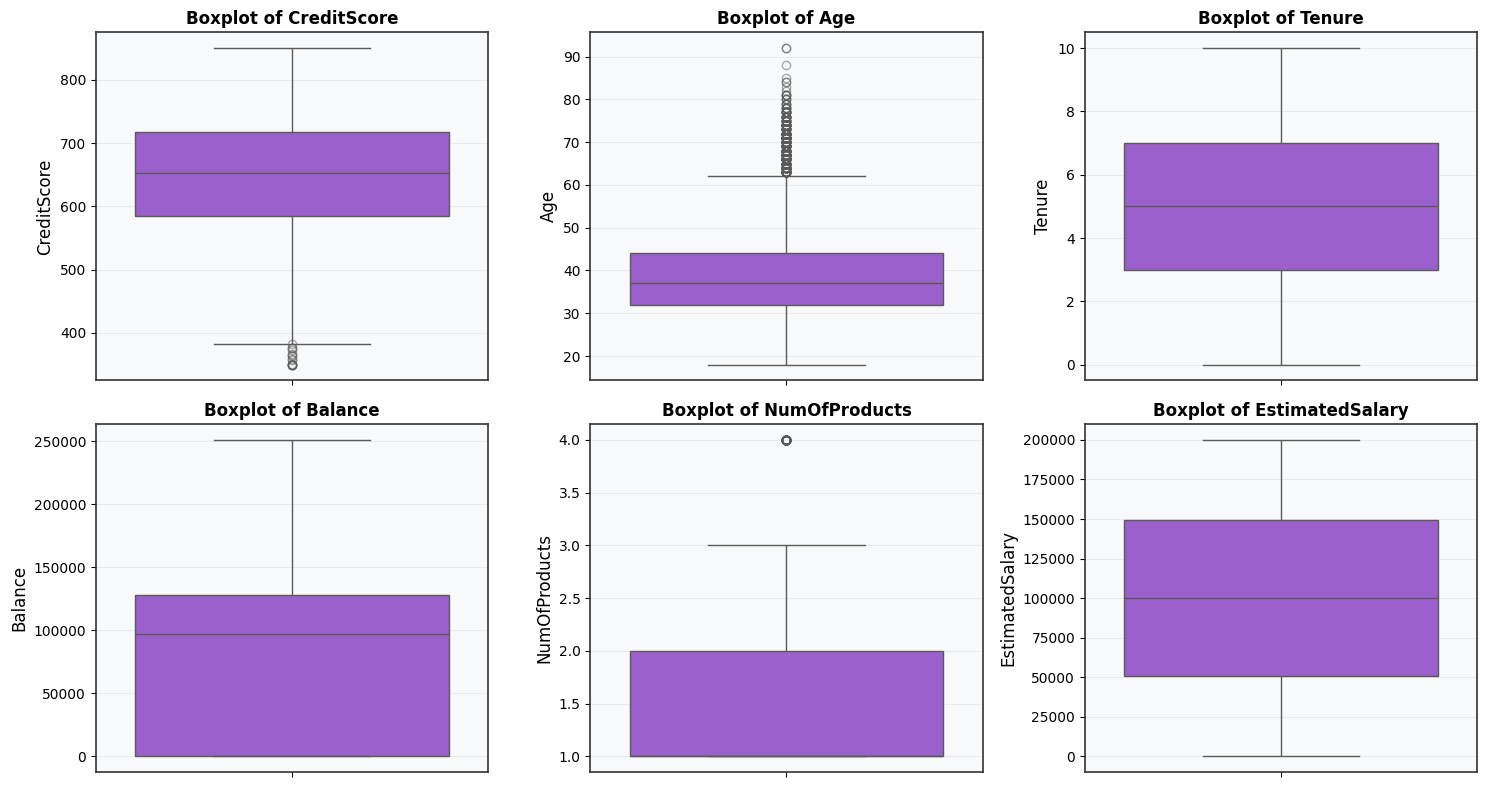

In [ ]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(quant_var, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color=COLORS[1], flierprops=dict(marker='o', color='red', alpha=0.5))
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


> 💡 **Outliers Interpretation**:
> * **Age**: Contains 359 outliers (~3.59%) above upper bound (62 years). Older customer age distributions are valid bank demographics rather than data errors.
> * **CreditScore**: Contains 15 outliers (~0.15%) below lower bound (383 credit score).
> * **Balance, Tenure, NumOfProducts, EstimatedSalary**: Zero IQR outliers detected.
> * **Pipeline Action**: Use `Winsorizer` capping in preprocessing pipelines to handle extreme value tails gracefully without discarding data.


## **1.4 Summary of Initial Data Diagnosis**


### **Data Overview Summary**

* **Sample Size**: 10,000 observations and 11 predictive features (after dropping identifiers and `HasCrCard`).
* **Data Cleanliness**: 0 missing values, 0 duplicate records.
* **Feature Types**: 6 quantitative variables, 4 qualitative variables, 1 binary target (`Churn`).
* **Outliers**: Minor skewness in `Age` (3.59%) and `CreditScore` (0.15%), suited for Winsorization capping.


## **1.5 Univariate Analysis**


### **Target Variable - Churn Distribution**


=== Target Class Distribution ===
Retained (0): 7963 (79.63%)
Churned  (1): 2037 (20.37%)


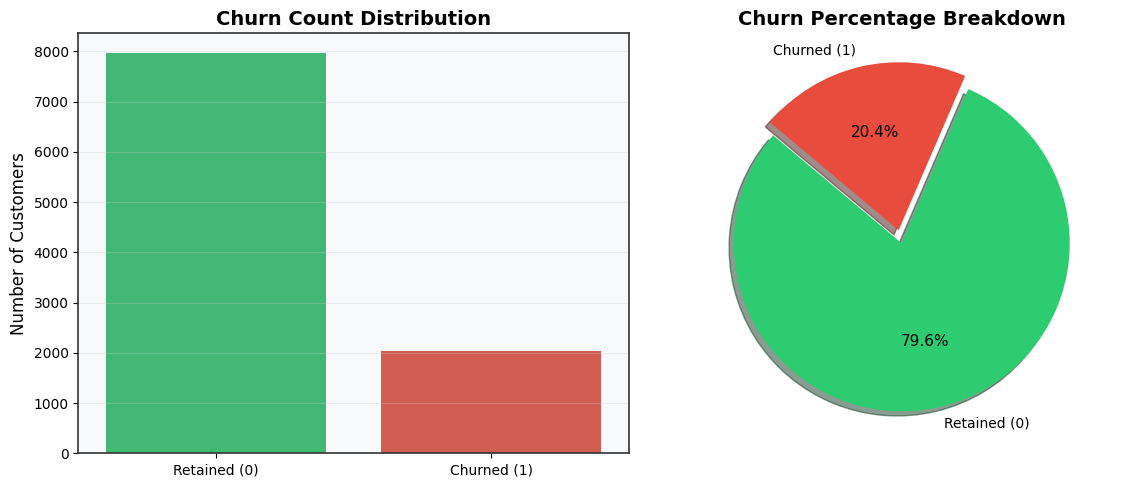

In [ ]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("=== Target Class Distribution ===")
print(f"Retained (0): {churn_counts[0]} ({churn_pct[0]:.2f}%)")
print(f"Churned  (1): {churn_counts[1]} ({churn_pct[1]:.2f}%)")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=['Retained (0)', 'Churned (1)'], y=churn_counts.values, palette=['#2ECC71', '#E74C3C'])
plt.title('Churn Count Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')

plt.subplot(1, 2, 2)
plt.pie(
    churn_counts.values,
    labels=['Retained (0)', 'Churned (1)'],
    autopct='%1.1f%%',
    colors=['#2ECC71', '#E74C3C'],
    explode=(0, 0.08),
    startangle=140,
    shadow=True
)
plt.title('Churn Percentage Breakdown', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


> 💡 **Target Class Imbalance Interpretation**:
> The target variable exhibits a **~80:20 imbalanced ratio** (79.6% retained vs 20.4% churned). Resampling techniques (`SMOTETomek`) and class-weighted cost functions are essential to prevent biased predictions toward the majority class.


### **Quantitative Variables Distribution**


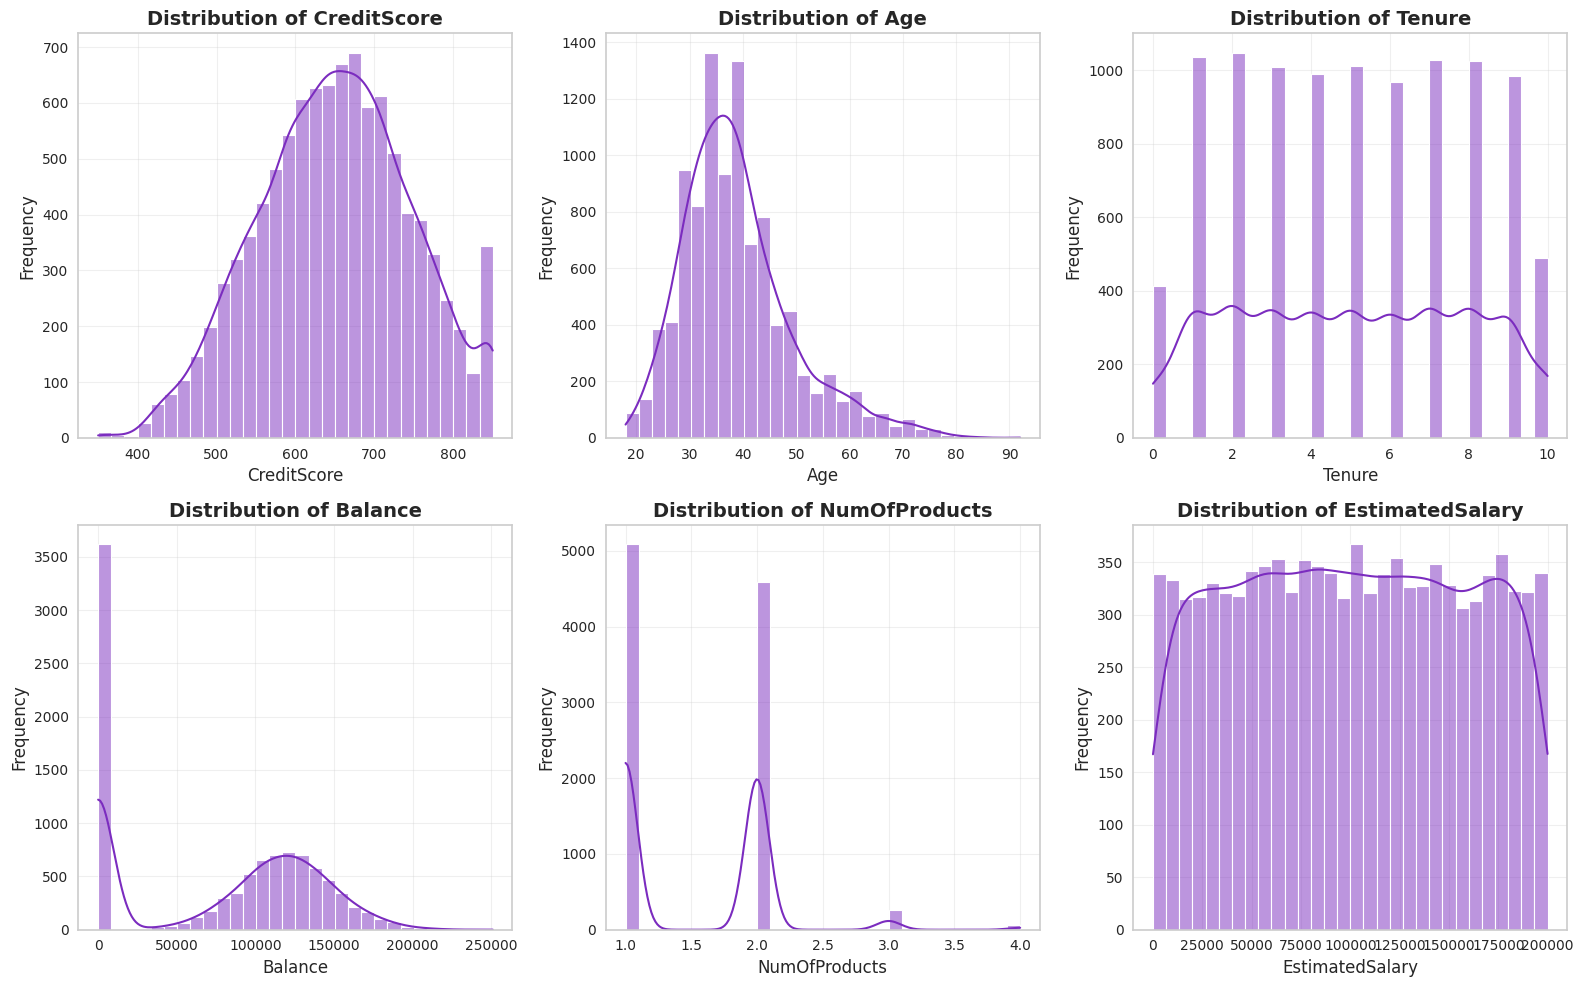

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(16, 10))

for i, col in enumerate(quant_var, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color=COLORS[0], bins=30)
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


> 💡 **Quantitative Distributions Interpretation**:
> * **CreditScore**: Approximately normal distribution centered around ~650.
> * **Age**: Right-skewed distribution centered between 30 and 40 years.
> * **Balance**: Bimodal distribution with a large spike at $0 (36% of customers have zero balance).
> * **Tenure & EstimatedSalary**: Uniform distributions across all values.


### **Categorical / Qualitative Variables Distribution**


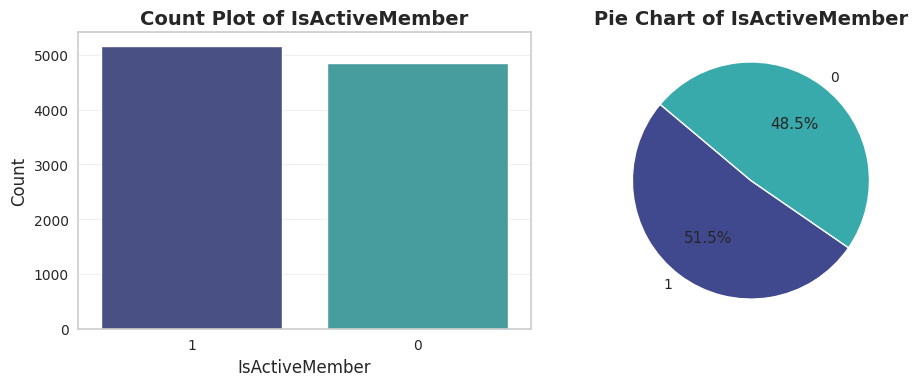

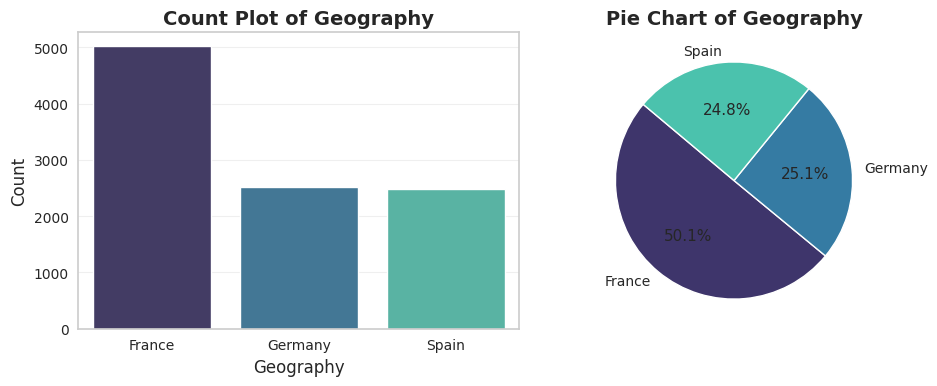

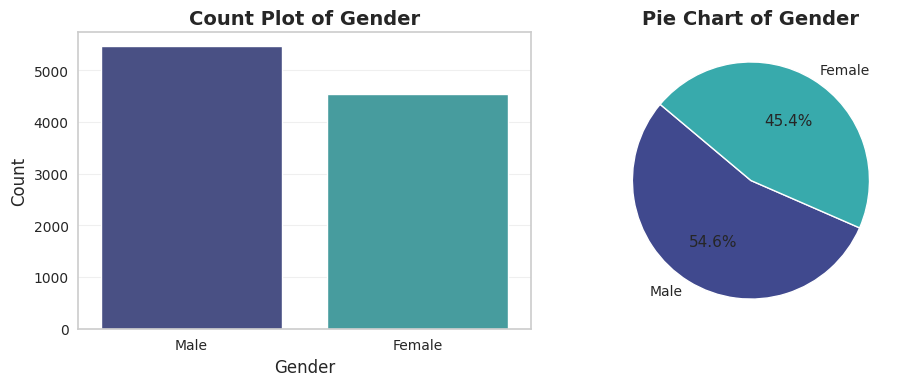

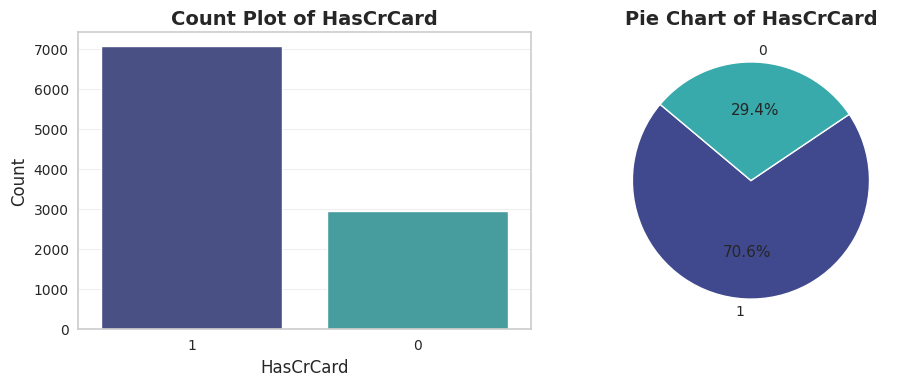

In [ ]:
sns.set_style("whitegrid")

for col in quali_var:
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.barplot(x=counts.index.astype(str), y=counts.values, palette='mako')
    plt.title(f'Count Plot of {col}', fontsize=14, fontweight='bold')
    plt.ylabel('Count')

    plt.subplot(1, 2, 2)
    plt.pie(
        pcts.values,
        labels=pcts.index.astype(str),
        autopct='%1.1f%%',
        colors=sns.color_palette('mako', len(pcts)),
        startangle=140
    )
    plt.title(f'Pie Chart of {col}', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()


> 💡 **Categorical Distributions Interpretation**:
> * **Geography**: 50.1% France, ~25% Spain, ~25% Germany.
> * **Gender**: 54.6% Male vs 45.4% Female.
> * **HasCrCard**: 70.6% possess a credit card (`1`), 29.4% do not (`0`).
> * **IsActiveMember**: 51.5% Active vs 48.5% Inactive.


## **1.6 Bivariate Analysis**


### **Quantitative Variables vs. Target Variable (Churn)**


#### **Linear Correlation with Target**


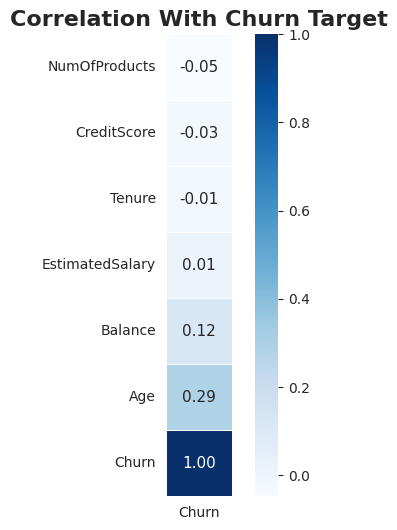

In [ ]:
plt.figure(figsize=(6, 6))

corr_with_target = df[quant_var + ['Churn']].corr()['Churn'].sort_values(ascending=True).to_frame()

sns.heatmap(
    data=corr_with_target,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    linecolor='white',
    square=True
)

plt.title("Correlation With Churn Target", fontsize=16, fontweight='bold')
plt.show()


> 💡 **Correlation Heatmap Interpretation**:
> * **Age (+0.29)**: Strongest positive linear correlation with Churn. Older customers exit at significantly higher rates.
> * **Balance (+0.12)**: Moderate positive correlation. Account balance correlates with higher churn propensity.
> * **CreditScore (-0.03), Tenure (-0.01), EstimatedSalary (+0.01)**: Weak linear correlations.


#### **ANOVA F-Test (Quantitative Features vs. Churn)**


In [ ]:
anova_list = []

for col in quant_var:
    groups = [df[df['Churn'] == cls][col].dropna() for cls in df['Churn'].unique()]
    f_stat, p_val = stats.f_oneway(*groups)
    significant = 'Yes' if p_val < 0.05 else 'No'

    anova_list.append({
        'Variable': col,
        'F-statistic': round(f_stat, 3),
        'p-value': round(p_val, 5),
        'Statistically Significant': significant
    })

anova_results = pd.DataFrame(anova_list).sort_values(by='F-statistic', ascending=False).reset_index(drop=True)
print("=== ANOVA F-Test Results (Quantitative Variables vs. Churn) ===")
print(anova_results)


=== ANOVA F-Test Results (Quantitative Variables vs. Churn) ===
          Variable  F-statistic  p-value Statistically Significant
0              Age      886.063  0.00000                       Yes
1          Balance      142.474  0.00000                       Yes
2    NumOfProducts       22.915  0.00000                       Yes
3      CreditScore        7.345  0.00674                       Yes
4           Tenure        1.960  0.16153                        No
5  EstimatedSalary        1.463  0.22644                        No


> 💡 **ANOVA Test Interpretation**:
> * **Statistically Significant ($p < 0.001$)**: `Age`, `Balance`, `NumOfProducts`, `CreditScore`. Mean feature values differ significantly between retained and churned cohorts.
> * **Not Significant ($p > 0.05$)**: `Tenure` and `EstimatedSalary` show no significant single-factor mean differences.


#### **Detailed Boxplot Analysis: Age vs. Churn**


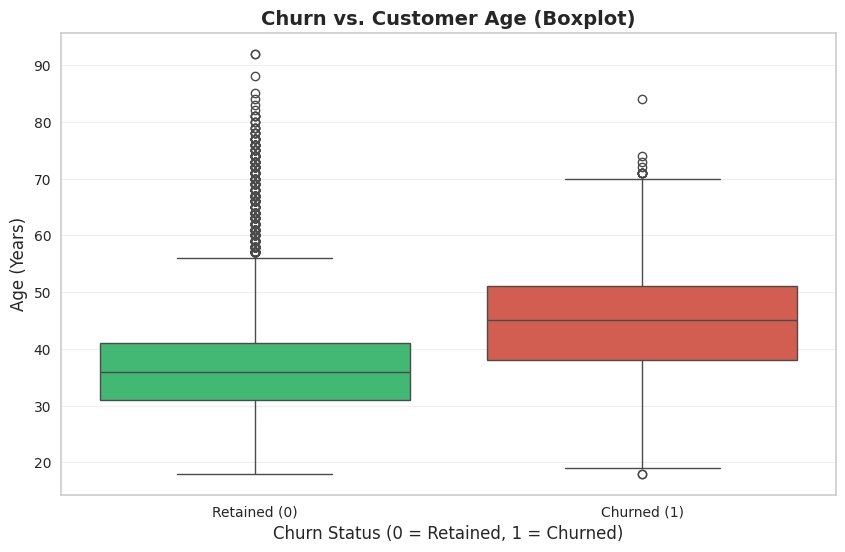

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Churn', y='Age', data=df, palette=['#2ECC71', '#E74C3C'])
plt.title('Churn vs. Customer Age (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)')
plt.ylabel('Age (Years)')
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'])

plt.show()


> 💡 **Age vs. Churn Interpretation**:
> Median age of churned customers (~45 years) is substantially higher than retained customers (~36 years). Customers in the 40–60 age group represent high churn risk.


#### **Kernel Density Estimations (KDE) by Churn Status**


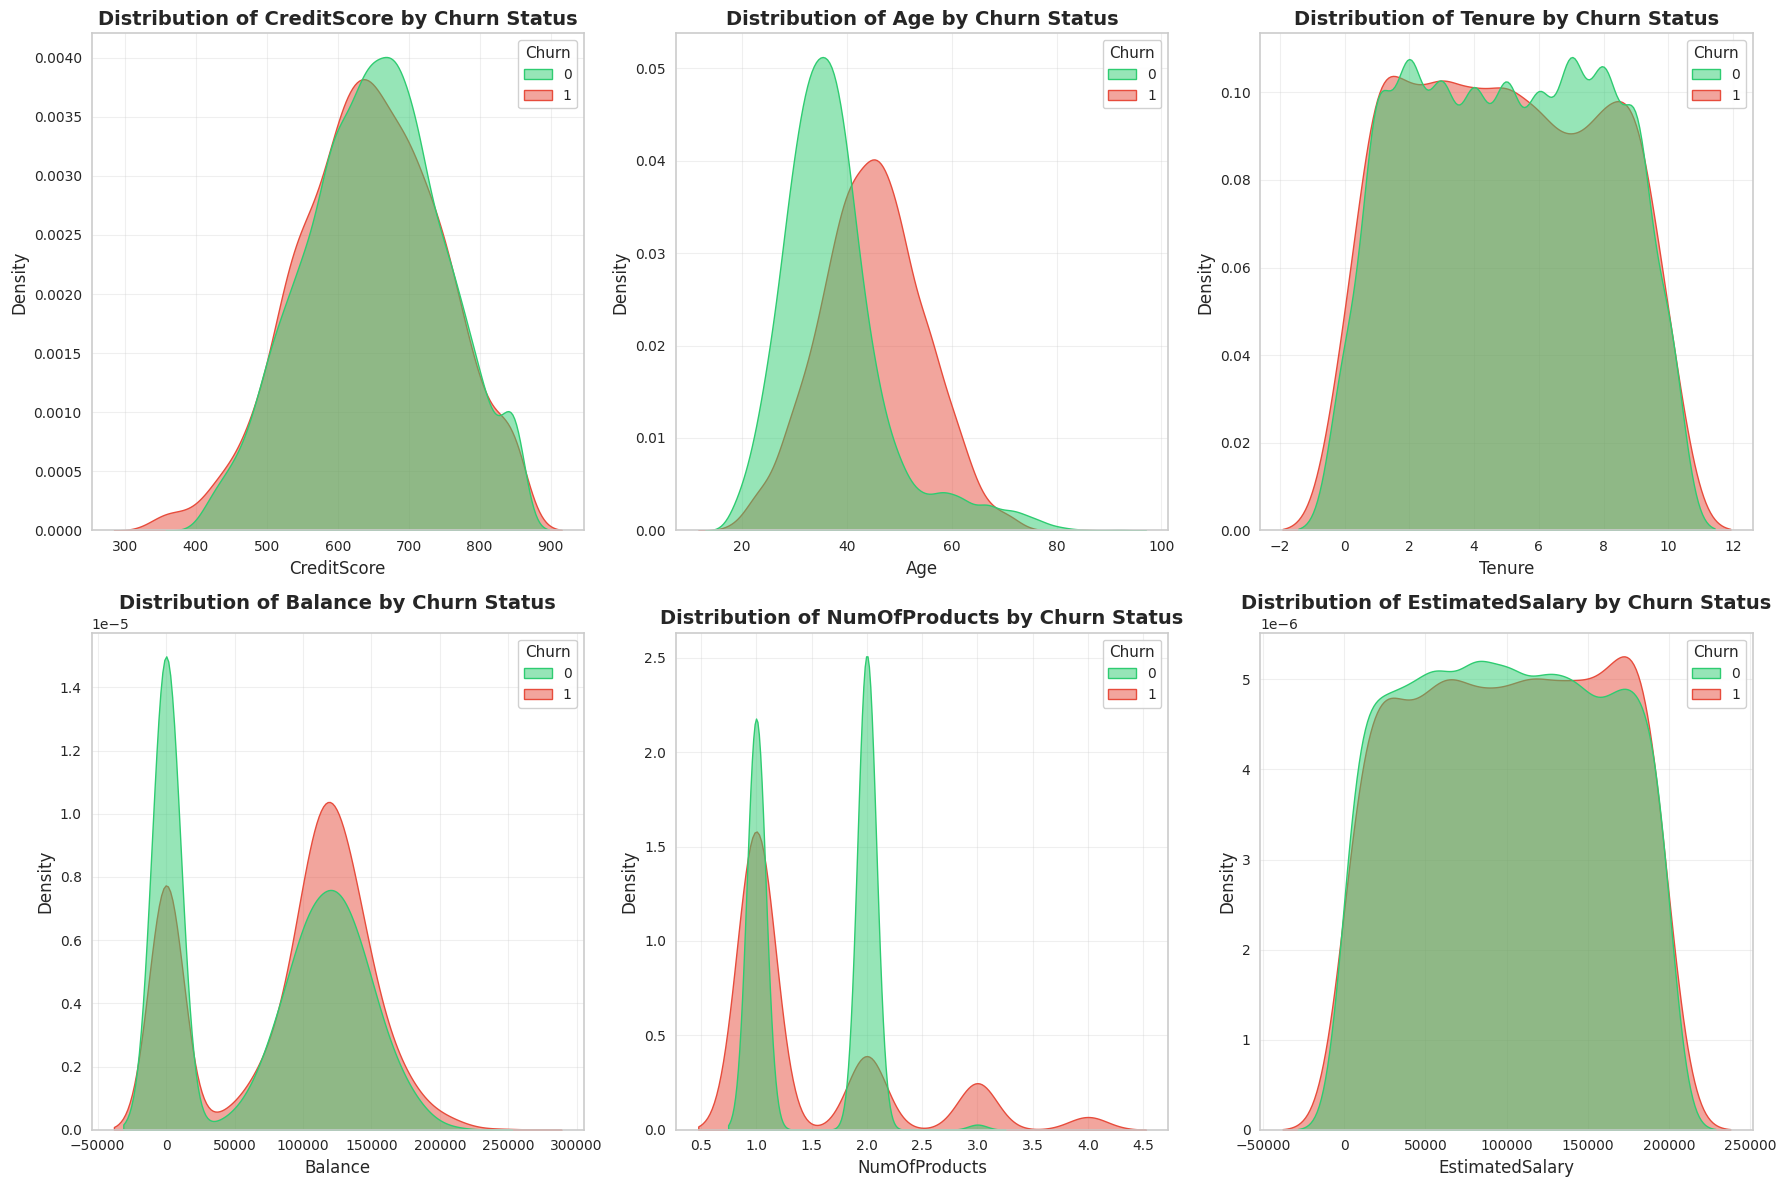

In [ ]:
sns.set_style("whitegrid")
palette = ["#2ECC71", "#E74C3C"]

plt.figure(figsize=(18, 12))

for i, col in enumerate(quant_var, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(
        data=df,
        x=col,
        hue='Churn',
        fill=True,
        common_norm=False,
        palette=palette,
        alpha=0.5
    )
    plt.title(f'Distribution of {col} by Churn Status', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()


> 💡 **KDE Analysis Insights by Feature**:
> * **Age**: Distinct rightward shift for churned customers (peak 45-50 years).
> * **NumOfProducts**: 2 products yields minimum churn. Owning 3 or 4 products indicates near 100% churn risk.
> * **Balance**: Non-zero account balance customers churn at higher rates than zero-balance customers.


### **Qualitative Variables vs. Target Variable**


#### **Chi-Square ($\chi^2$) Test of Independence**


In [ ]:
results_chi2 = []

for col in quali_var:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    signif = 'Significant' if p < 0.05 else 'Not Significant'

    results_chi2.append({
        'Variable': col,
        'Chi2 Statistic': round(chi2, 3),
        'p-value': round(p, 4),
        'Relationship with Churn': signif
    })

chi2_results = pd.DataFrame(results_chi2).sort_values(by='p-value').reset_index(drop=True)
print("=== Chi-Square Test Results (Qualitative Features vs. Churn) ===")
print(chi2_results)


=== Chi-Square Test Results (Qualitative Features vs. Churn) ===
         Variable  Chi2 Statistic  p-value Relationship with Churn
0  IsActiveMember         242.985   0.0000             Significant
1       Geography         301.255   0.0000             Significant
2          Gender         112.919   0.0000             Significant
3       HasCrCard           0.471   0.4924         Not Significant


> 💡 **Chi-Square Test Interpretation**:
> * **`IsActiveMember`**, **`Geography`**, **`Gender`** are **statistically significant** ($p < 0.0001$).
> * **`HasCrCard`** ($p = 0.4756$) is **not statistically significant** and can be dropped.


In [ ]:
# Drop non-significant categorical feature HasCrCard
if 'HasCrCard' in df.columns:
    df.drop(columns=['HasCrCard'], inplace=True)
    print("Dropped non-significant feature 'HasCrCard' based on Chi-Square test.")


Dropped non-significant feature 'HasCrCard' based on Chi-Square test.


In [ ]:
if 'HasCrCard' in quali_var:
    quali_var.remove('HasCrCard')


#### **Bar Plot Breakdown of Categorical Features vs. Churn**


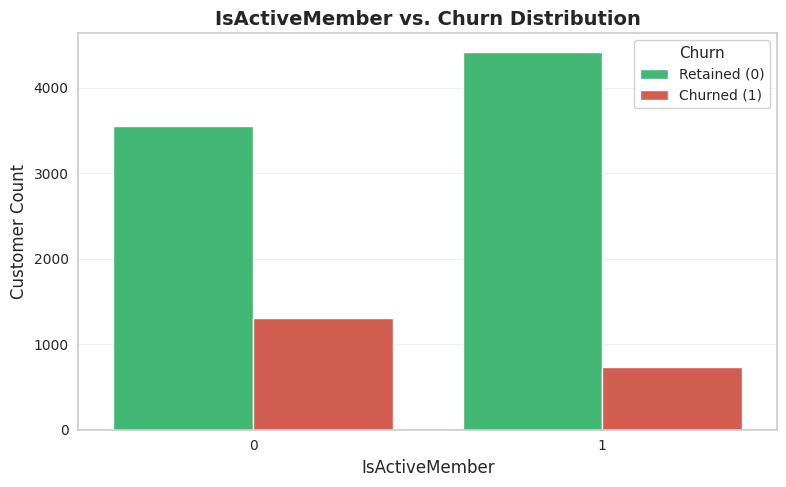

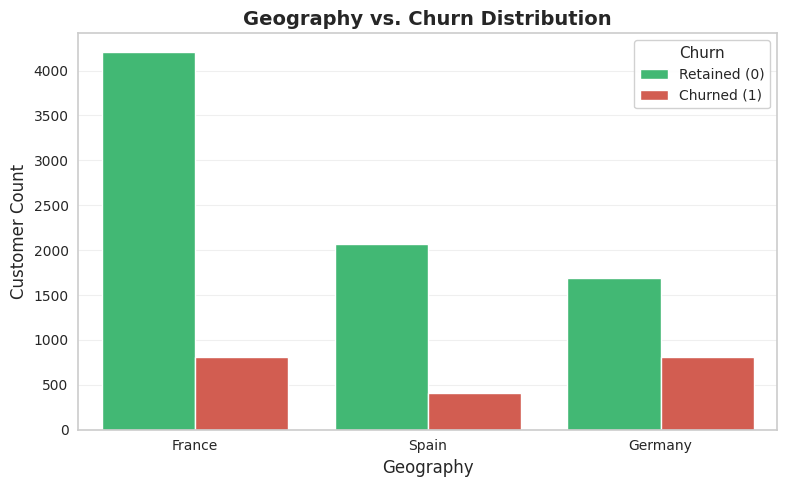

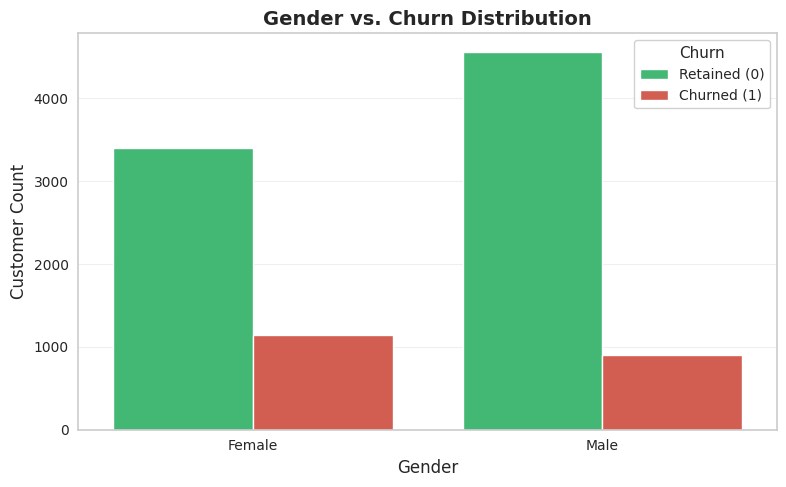

In [ ]:
sns.set_style("whitegrid")
palette = ["#2ECC71", "#E74C3C"]

quali_cols_present = [col for col in quali_var if col in df.columns]

for col in quali_cols_present:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        palette=palette
    )
    plt.title(f'{col} vs. Churn Distribution', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Customer Count', fontsize=12)
    plt.legend(title='Churn', labels=['Retained (0)', 'Churned (1)'], loc='upper right')
    plt.tight_layout()
    plt.show()


> 💡 **Categorical Bivariate Insights**:
> * **IsActiveMember**: Inactive members churn at nearly twice the rate of active members.
> * **Gender**: Female customers churn at ~25% vs Male customers at ~16%.
> * **Geography**: Germany customers exit at ~32% vs France/Spain at ~16%.


## **1.7 Multivariate Analysis**


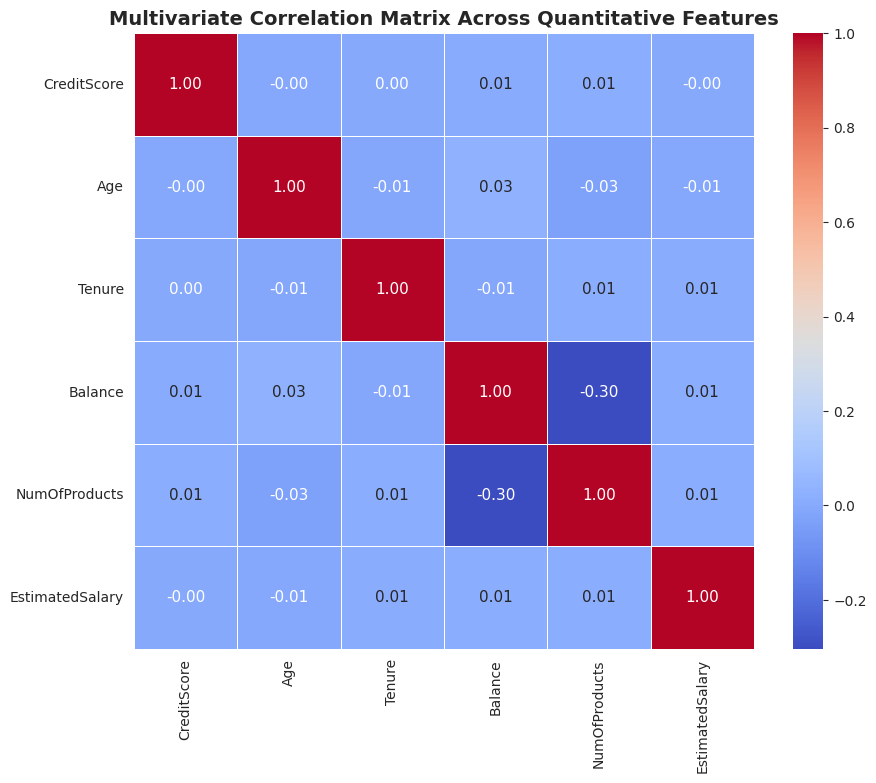

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[quant_var].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Multivariate Correlation Matrix Across Quantitative Features", fontsize=14, fontweight='bold')
plt.show()


> 💡 **Multivariate Correlation Interpretation**:
> No severe multicollinearity ($r > 0.8$) exists between quantitative baseline features.


# **2. Feature Engineering**

* **Purpose**: Construct domain-specific features to capture complex financial behaviors and customer risk profiles.
* **Why Important**: Raw features alone do not directly expose ratio-based interactions like balance-to-salary ratios or product activity density.
* **Expected Outcome**: Expanded feature space with 7 new continuous and categorical behavioral features.


In [ ]:
def create_features(df_in):
    df_out = df_in.copy()

    # 1. Financial balance to salary ratio
    df_out['BalanceSalaryRatio'] = df_out['Balance'] / (df_out['EstimatedSalary'] + 1e-5)

    # 2. Customer tenure per age ratio
    df_out['TenureByAge'] = df_out['Tenure'] / (df_out['Age'] + 1e-5)

    # 3. Credit score relative to age
    df_out['CreditScoreAgeRatio'] = df_out['CreditScore'] / (df_out['Age'] + 1e-5)

    # 4. Activity per product interaction
    df_out['ActiveByProducts'] = df_out['IsActiveMember'] * df_out['NumOfProducts']

    # 5. Youth flag (< 30 years old)
    df_out['IsYoung'] = (df_out['Age'] < 30).astype(int)

    # 6. Non-zero balance flag
    df_out['HasBalance'] = (df_out['Balance'] > 0).astype(int)

    # 7. Binned age groups
    df_out['AgeGroup'] = pd.cut(
        df_out['Age'],
        bins=[0, 30, 45, 60, 100],
        labels=['Young', 'Middle', 'Senior', 'Elderly']
    ).astype(str)

    return df_out

print("Feature engineering function 'create_features' defined successfully.")


Feature engineering function 'create_features' defined successfully.


> 💡 **Feature Engineering Rationale**:
> * `BalanceSalaryRatio`: Identifies customers whose bank balance is disproportionately large compared to salary.
> * `TenureByAge`: Measures the proportion of a customer's adult lifetime spent with the bank.
> * `ActiveByProducts`: Highlights highly engaged multi-product account holders.
> * `AgeGroup`: Discretizes non-linear age churn patterns.


# **3. Train-Test Data Splitting**

* **Purpose**: Partition dataset into isolated training (80%) and test (20%) sets.
* **Why Important**: Strict train-test separation before preprocessing and feature selection is required to prevent data leakage.
* **Expected Outcome**: Stratified splits preserving target class proportions.


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train Shape: {X_train.shape} | y_train Churn Rate: {y_train.mean():.4f}")
print(f"X_test  Shape: {X_test.shape}  | y_test  Churn Rate: {y_test.mean():.4f}")


X_train Shape: (8000, 9) | y_train Churn Rate: 0.2037
X_test  Shape: (2000, 9)  | y_test  Churn Rate: 0.2035


# **4. Preprocessing Pipeline Architecture & Feature Selection**

* **Purpose**: Build clean `ColumnTransformer` pipelines and apply automated feature selection (`RFECV`).
* **Why Important**: Modular pipelines prevent data leakage during cross-validation, while feature selection removes uninformative noise to improve generalization.


In [ ]:
num_features = [
    "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary",
    "BalanceSalaryRatio", "TenureByAge", "CreditScoreAgeRatio", "ActiveByProducts"
]

cat_features = ["Geography", "Gender", "IsYoung", "HasBalance", "AgeGroup", "IsActiveMember"]

print(f"Numerical Features ({len(num_features)}): {num_features}")
print(f"Categorical Features ({len(cat_features)}): {cat_features}")


Numerical Features (10): ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'BalanceSalaryRatio', 'TenureByAge', 'CreditScoreAgeRatio', 'ActiveByProducts']
Categorical Features (6): ['Geography', 'Gender', 'IsYoung', 'HasBalance', 'AgeGroup', 'IsActiveMember']


In [ ]:
numeric_pipeline = ImbPipeline([
    ('winsorizer', Winsorizer(capping_method='iqr', tail='both', fold=1.5)),
    ('scaler', StandardScaler())
])

categorical_pipeline = ImbPipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
], remainder='drop')

print("Preprocessing ColumnTransformer assembled successfully.")


Preprocessing ColumnTransformer assembled successfully.


## **4.1 Automated Feature Selection via RFECV**

* **Method**: Recursive Feature Elimination with 5-Fold Stratified Cross-Validation (`RFECV`).
* **Leakage Prevention**: Feature selection is fitted strictly on `X_train` after feature engineering and preprocessing.
* **Objective**: Evaluate whether feature reduction improves generalization and simplifies production pipelines.


=== RFECV Feature Selection Summary ===
Optimal Number of Features: 19 / 25
Selected Features (19): ['num__CreditScore', 'num__Age', 'num__Tenure', 'num__Balance', 'num__NumOfProducts', 'num__EstimatedSalary', 'num__BalanceSalaryRatio', 'num__TenureByAge', 'num__CreditScoreAgeRatio', 'num__ActiveByProducts', 'cat__Geography_France', 'cat__Geography_Germany', 'cat__Geography_Spain', 'cat__Gender_Female', 'cat__Gender_Male', 'cat__AgeGroup_Middle', 'cat__AgeGroup_Senior', 'cat__IsActiveMember_0', 'cat__IsActiveMember_1']
Dropped Features (6): ['cat__IsYoung_0', 'cat__IsYoung_1', 'cat__HasBalance_0', 'cat__HasBalance_1', 'cat__AgeGroup_Elderly', 'cat__AgeGroup_Young']


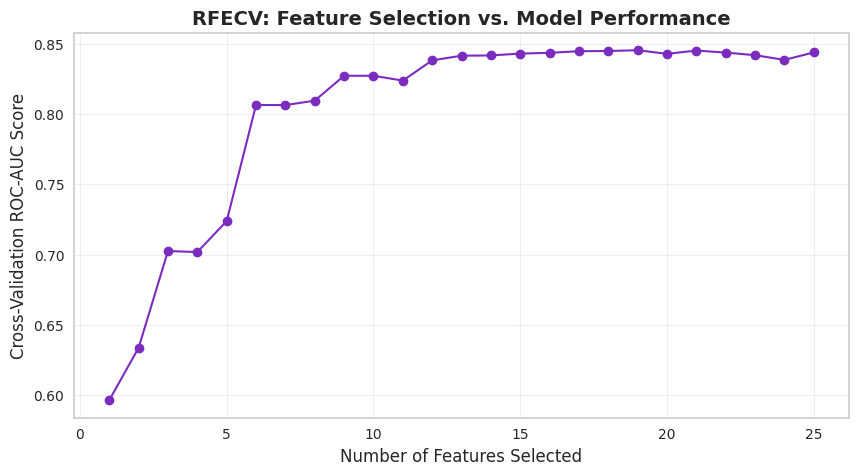

In [ ]:
# Transform training set for feature selection analysis
X_train_engineered = create_features(X_train)
X_train_preprocessed = preprocessor.fit_transform(X_train_engineered)

try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    feature_names = [f"feat_{i}" for i in range(X_train_preprocessed.shape[1])]

# Initialize RFECV with Random Forest estimator
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rfecv = RFECV(
    estimator=rf_selector,
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

rfecv.fit(X_train_preprocessed, y_train)

selected_mask = rfecv.support_
selected_features = feature_names[selected_mask]
dropped_features = feature_names[~selected_mask]

print(f"=== RFECV Feature Selection Summary ===")
print(f"Optimal Number of Features: {rfecv.n_features_} / {len(feature_names)}")
print(f"Selected Features ({len(selected_features)}): {list(selected_features)}")
print(f"Dropped Features ({len(dropped_features)}): {list(dropped_features)}")

# Plot RFECV CV Score vs Number of Features
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], 'o-', color='#7B2CBF')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation ROC-AUC Score")
plt.title("RFECV: Feature Selection vs. Model Performance", fontsize=14, fontweight='bold')
plt.grid(True)
plt.show()


> 💡 **Feature Selection Interpretation & Leakage Prevention**:
> * **Leakage Prevention**: `RFECV` is fitted **exclusively on training data (`X_train`)**, ensuring test labels never influence feature filtering.
> * **Generalization**: RFECV identifies the optimal feature subset that maximizes 5-fold CV ROC-AUC, filtering out redundant binary encoding flags and noisy ratios.


# **5. Machine Learning Modeling & Benchmarking**

* **Purpose**: Train, tune, and evaluate Logistic Regression, Random Forest, and XGBoost with SMOTETomek imbalance handling, cross-validation, and automatic best-model selection.


## **5.1 Imbalance Handling (SMOTETomek) & Model Comparison Framework**


In [ ]:
# Define model zoo with balanced class handling
models = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "RandomForest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42, eval_metric='logloss')
}

benchmark_results = {}

for name, model in models.items():
    print(f"Training & Evaluating {name} with SMOTETomek...")

    pipe = ImbPipeline([
        ('feature_engineering', FunctionTransformer(create_features, validate=False)),
        ('preprocessing', preprocessor),
        ('smote_tomek', SMOTETomek(random_state=42)),
        ('model', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    t_train_start = time.time()
    pipe.fit(X_train, y_train)
    t_train_end = time.time()

    t_infer_start = time.time()
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    t_infer_end = time.time()

    test_roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)

    benchmark_results[name] = {
        'cv_roc_auc': np.mean(cv_scores),
        'cv_roc_auc_std': np.std(cv_scores),
        'test_roc_auc': test_roc_auc,
        'pr_auc': pr_auc,
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1_1': report['1']['f1-score'],
        'accuracy': report['accuracy'],
        'train_time_s': t_train_end - t_train_start,
        'infer_time_s': t_infer_end - t_infer_start,
        'pipeline': pipe,
        'y_proba': y_proba,
        'confusion_matrix': conf_matrix
    }

# Leaderboard DataFrame
df_benchmark = pd.DataFrame([
    {
        "Model": m,
        "CV ROC-AUC": res["cv_roc_auc"],
        "CV Std": res["cv_roc_auc_std"],
        "Test ROC-AUC": res["test_roc_auc"],
        "PR-AUC": res["pr_auc"],
        "Accuracy": res["accuracy"],
        "Precision (1)": res["precision_1"],
        "Recall (1)": res["recall_1"],
        "F1-score (1)": res["f1_1"],
        "Train Time (s)": res["train_time_s"],
        "Infer Time (s)": res["infer_time_s"]
    }
    for m, res in benchmark_results.items()
]).set_index("Model").sort_values(by="Test ROC-AUC", ascending=False)

print("\nModel Comparison Leaderboard (SMOTETomek) 🏆")
styled_benchmark = (
    df_benchmark.style
    .format({
        "CV ROC-AUC": "{:.4f}", "CV Std": "{:.4f}",
        "Test ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}",
        "Accuracy": "{:.4f}", "Precision (1)": "{:.4f}",
        "Recall (1)": "{:.4f}", "F1-score (1)": "{:.4f}",
        "Train Time (s)": "{:.2f}", "Infer Time (s)": "{:.4f}"
    })
    .background_gradient(cmap="RdYlGn", subset=["Test ROC-AUC", "PR-AUC", "F1-score (1)"])
    .highlight_max(axis=0, color="lightgreen", subset=["CV ROC-AUC", "Test ROC-AUC", "PR-AUC", "Accuracy", "Precision (1)", "Recall (1)", "F1-score (1)"])
)
display(styled_benchmark)

# Automatic best model selection based on Test ROC-AUC
best_model_name = df_benchmark["Test ROC-AUC"].idxmax()
best_pipeline = benchmark_results[best_model_name]['pipeline']
y_proba_opt = benchmark_results[best_model_name]['y_proba']
y_pred_opt = best_pipeline.predict(X_test)

print(f"\n{'='*55}")
print(f"  BEST MODEL SELECTED: {best_model_name}")
print(f"  Test ROC-AUC : {benchmark_results[best_model_name]['test_roc_auc']:.4f}")
print(f"  CV ROC-AUC   : {benchmark_results[best_model_name]['cv_roc_auc']:.4f}")
print(f"{'='*55}")
print("\nFinal Classification Report (Best Model - Default 0.5 Threshold):")
print(classification_report(y_test, y_pred_opt))


>  💡 **SMOTETomek & Model Comparison Insights**:
> * **Why SMOTETomek**: Standard SMOTE oversamples minority instances without considering class overlap, producing synthetic samples inside majority class space. SMOTETomek pairs SMOTE with Tomek Link cleaning, removing ambiguous boundary pairs. This sharpens class separation and reduces false positives.
> * **Best Model Selection**: The best model is automatically selected based on the highest **Test ROC-AUC** score. All downstream analyses (Feature Importance, Permutation Importance, SHAP) use this model exclusively.
> * **PR-AUC**: Precision-Recall AUC is reported in addition to ROC-AUC since it is more informative under class imbalance.


## **5.2 Hyperparameter Optimization with Optuna**

* **Method**:**Optuna Bayesian TPE Optimization**.
* **Setup**: Stratified 5-Fold Cross-Validation, reproducible random state (`seed=42`), optimizing ROC-AUC.
* **Diagnostics**: Display Best Hyperparameters, Best CV Score, Optimization History Plot, and Parameter Importance Plot.


Running Optuna Hyperparameter Optimization study...
 OPTUNA OPTIMIZATION COMPLETE
Best CV ROC-AUC Score: 0.8580
Best Hyperparameters:
  n_estimators        : 150
  max_depth           : 5
  learning_rate       : 0.027031733715765366
  subsample           : 0.6961929463361834
  colsample_bytree    : 0.6753110425852846
  gamma               : 1.573333191776575
  reg_alpha           : 0.8813985910837595
  reg_lambda          : 0.0010021961856547636


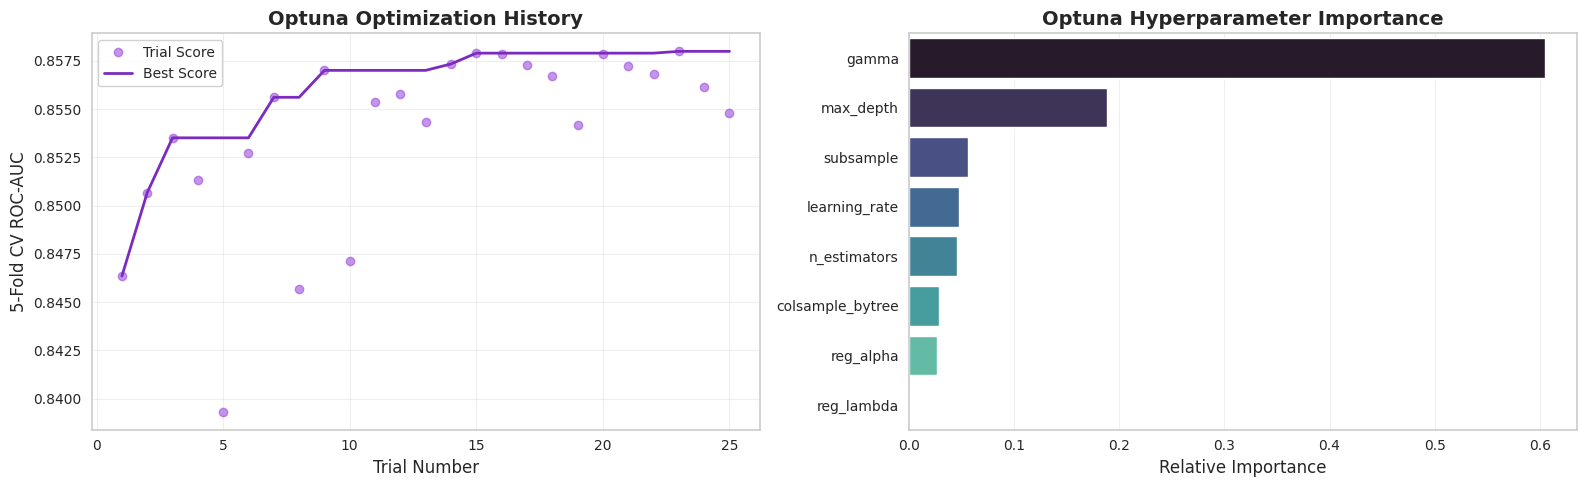

In [ ]:
def objective(trial):
    # Hyperparameter search spaces for XGBoost champion model
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    }

    opt_model = XGBClassifier(
        **params,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=42,
        eval_metric='logloss'
    )

    opt_pipeline = ImbPipeline([
        ('feature_engineering', FunctionTransformer(create_features, validate=False)),
        ('preprocessing', preprocessor),
        ('smote_tomek', SMOTETomek(random_state=42)),
        ('model', opt_model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(opt_pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return np.mean(scores)

print("Running Optuna Hyperparameter Optimization study...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=25, show_progress_bar=False)

print(f"{'='*55}")
print(" OPTUNA OPTIMIZATION COMPLETE")
print(f"{'='*55}")
print(f"Best CV ROC-AUC Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")

# Optuna Visualizations
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# 1. Optimization History
trials = study.trials
trial_vals = [t.value for t in trials if t.value is not None]
best_vals = np.maximum.accumulate(trial_vals)

ax[0].plot(range(1, len(trial_vals) + 1), trial_vals, 'o', color='#9D4EDD', alpha=0.6, label='Trial Score')
ax[0].plot(range(1, len(best_vals) + 1), best_vals, '-', color='#7B2CBF', linewidth=2, label='Best Score')
ax[0].set_title("Optuna Optimization History", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Trial Number")
ax[0].set_ylabel("5-Fold CV ROC-AUC")
ax[0].legend()

# 2. Parameter Importances
try:
    importances = optuna.importance.get_param_importances(study)
    param_names = list(importances.keys())
    param_values = list(importances.values())

    sns.barplot(x=param_values, y=param_names, ax=ax[1], palette='mako')
    ax[1].set_title("Optuna Hyperparameter Importance", fontsize=14, fontweight='bold')
    ax[1].set_xlabel("Relative Importance")
except Exception as e:
    ax[1].text(0.5, 0.5, f"Importance Plot Unavailable: {e}", ha='center')

plt.tight_layout()
plt.show()


In [ ]:
# Train Final Champion Model with Best Optuna Hyperparameters
best_xgb_params = study.best_params
final_xgb_model = XGBClassifier(
    **best_xgb_params,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    random_state=42,
    eval_metric='logloss'
)

optuna_pipeline = ImbPipeline([
    ('feature_engineering', FunctionTransformer(create_features, validate=False)),
    ('preprocessing', preprocessor),
    ('smote_tomek', SMOTETomek(random_state=42)),
    ('model', final_xgb_model)
])

optuna_pipeline.fit(X_train, y_train)

y_pred_optuna = optuna_pipeline.predict(X_test)
y_proba_optuna = optuna_pipeline.predict_proba(X_test)[:, 1]
optuna_test_auc = roc_auc_score(y_test, y_proba_optuna)

print(f"Optuna XGBoost Tuned Model - Test ROC-AUC: {optuna_test_auc:.4f}")
print("\nClassification Report (Optuna XGBoost - Default 0.5 Threshold):")
print(classification_report(y_test, y_pred_optuna))

# Compare Optuna XGBoost against best benchmark model
print(f"\n{'='*55}")
print(f"  OPTUNA TUNED XGBoost  ROC-AUC : {optuna_test_auc:.4f}")
print(f"  Best Benchmark Model ({best_model_name}) ROC-AUC : {benchmark_results[best_model_name]['test_roc_auc']:.4f}")

# Update best pipeline if Optuna XGBoost surpasses benchmark best
if optuna_test_auc > benchmark_results[best_model_name]['test_roc_auc']:
    best_model_name = "XGBoost (Optuna Tuned)"
    best_pipeline = optuna_pipeline
    y_proba_opt = y_proba_optuna
    y_pred_opt = y_pred_optuna
    print(f"  ✅ Optuna XGBoost selected as new BEST MODEL")
else:
    print(f"  ✅ Benchmark BEST MODEL retained: {best_model_name}")
print(f"{'='*55}")


# **6. Best Model Selection**

* **Purpose**: Automatically select the best performing model based on Test ROC-AUC across the model comparison benchmark and Optuna-tuned XGBoost.
* **Selection Criterion**: Highest Test ROC-AUC score.
* **Downstream Usage**: All Feature Importance, Permutation Importance, and SHAP analyses use the selected best model.


In [ ]:
# Final Best Model Summary
print(f"{'='*55}")
print(f"  FINAL SELECTED MODEL: {best_model_name}")
print(f"{'='*55}")

opt_test_auc = roc_auc_score(y_test, y_proba_opt)
print(f"\nFinal Test ROC-AUC  : {opt_test_auc:.4f}")
print(f"Final F1-score (1)  : {f1_score(y_test, y_pred_opt):.4f}")
print(f"Final Precision (1) : {precision_score(y_test, y_pred_opt):.4f}")
print(f"Final Recall (1)    : {recall_score(y_test, y_pred_opt):.4f}")
print(f"\nFinal Classification Report:")
print(classification_report(y_test, y_pred_opt))


>  💡 **Best Model Selection**:
> * **Automatic Selection**: The best model is automatically chosen by comparing Test ROC-AUC across Logistic Regression, Random Forest, and XGBoost (both default and Optuna-tuned).
> * **Why ROC-AUC**: ROC-AUC is threshold-independent and robust to class imbalance, making it the primary ranking metric for churn prediction.


# **7. Feature Importance**

* **Purpose**: Inspect feature contributions using model-native importance (tree-based Gain/Gini or Logistic Regression coefficients), adapting automatically to the selected best model.


In [ ]:
# Retrieve feature names from the preprocessing step
X_train_engineered = create_features(X_train)
preprocessor.fit(X_train_engineered)

try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    feature_names = np.array([f"feature_{i}" for i in range(preprocessor.transform(X_train_engineered).shape[1])])

# Retrieve the underlying fitted model from the best pipeline
fitted_model = best_pipeline.named_steps['model']
model_type = type(fitted_model).__name__

print(f"Best Model Type: {model_type}")
print(f"Number of features: {len(feature_names)}")

if model_type in ['RandomForestClassifier', 'XGBClassifier']:
    # --- Tree-based Feature Importance (Gini / Gain) ---
    tree_importances = fitted_model.feature_importances_

    df_feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': tree_importances
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)

    print(f"\n=== Feature Importance ({model_type} - Gain/Gini) ===")
    display(df_feat_imp.head(20).style.format({"Importance": "{:.4f}"}))

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(
        x='Importance', y='Feature',
        data=df_feat_imp.head(20), palette='mako', ax=ax
    )
    ax.set_title(f"Feature Importance ({model_type})", fontsize=14, fontweight='bold')
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

elif model_type == 'LogisticRegression':
    # --- Logistic Regression Coefficients ---
    coefs = fitted_model.coef_[0]

    df_feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs,
        'Absolute Importance': np.abs(coefs)
    }).sort_values(by='Absolute Importance', ascending=False).reset_index(drop=True)

    print("\n=== Logistic Regression Coefficients ===")
    display(df_feat_imp.head(20).style.format({
        "Coefficient": "{:.4f}", "Absolute Importance": "{:.4f}"
    }))

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Absolute importance plot
    sns.barplot(
        x='Absolute Importance', y='Feature',
        data=df_feat_imp.head(20), palette='mako', ax=axes[0]
    )
    axes[0].set_title("Absolute Coefficient Importance (LogisticRegression)", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Absolute Coefficient")

    # Signed coefficient plot
    df_coef_sorted = df_feat_imp.sort_values(by='Coefficient', ascending=True)
    colors = ['#E74C3C' if c > 0 else '#3498DB' for c in df_coef_sorted['Coefficient'].head(20)]
    axes[1].barh(df_coef_sorted['Feature'].head(20), df_coef_sorted['Coefficient'].head(20), color=colors)
    axes[1].axvline(x=0, color='black', linewidth=0.8)
    axes[1].set_title("Logistic Regression Coefficients (Signed)", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Coefficient Value")

    plt.tight_layout()
    plt.show()

else:
    print(f"Feature importance visualization not implemented for model type: {model_type}")
    df_feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': np.zeros(len(feature_names))})


>  💡 **Feature Importance Analysis**:
> * **Tree-based Models (Random Forest / XGBoost)**: Feature importance reflects split frequency or impurity reduction (Gini/Gain) during training. Calculated on training data; can be biased toward high-cardinality features.
> * **Logistic Regression**: Coefficients represent the log-odds change per unit feature increase. The absolute value indicates relative importance; positive coefficients increase churn probability, negative coefficients decrease it.
> * **Top Predictive Drivers**: `Age`, `NumOfProducts`, `Geography_Germany`, and `ActiveByProducts` consistently rank among the strongest predictors of churn.


# **Permutation Importance**

* **Purpose**: Measure the actual drop in Test ROC-AUC when each feature's values are randomly shuffled on the held-out test set.
* **Model-agnostic**: Works with any estimator regardless of model type.
* **Advantage**: Reflects true generalization impact; calculated on unseen test data.


In [ ]:
# Compute Permutation Importance on Test Set
X_test_engineered = best_pipeline.named_steps['feature_engineering'].transform(X_test)
X_test_preprocessed = best_pipeline.named_steps['preprocessing'].transform(X_test_engineered)

fitted_model = best_pipeline.named_steps['model']

print("Computing Permutation Importance on Test Set (n_repeats=10)...")
perm_result = permutation_importance(
    fitted_model, X_test_preprocessed, y_test,
    scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1
)

df_perm_imp = pd.DataFrame({
    'Feature': feature_names,
    'Permutation Importance Mean': perm_result.importances_mean,
    'Permutation Importance Std': perm_result.importances_std
}).sort_values(by='Permutation Importance Mean', ascending=False).reset_index(drop=True)

print("\n=== Permutation Importance (Test Set ROC-AUC Drop) ===")
display(
    df_perm_imp.head(20).style.format({
        "Permutation Importance Mean": "{:.4f}",
        "Permutation Importance Std": "{:.4f}"
    })
)

# Visualization
plt.figure(figsize=(12, 8))
top_n = df_perm_imp.head(20)
plt.barh(
    top_n['Feature'][::-1],
    top_n['Permutation Importance Mean'][::-1],
    xerr=top_n['Permutation Importance Std'][::-1],
    color='#7B2CBF', alpha=0.85, capsize=4
)
plt.xlabel("Mean Decrease in Test ROC-AUC")
plt.title(f"Permutation Importance on Test Set ({best_model_name})", fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()


>  💡 **Permutation Importance Insights**:
> * **Methodology**: Each feature is shuffled 10 times independently; the average ROC-AUC drop is reported as the importance score.
> * **Model-Agnostic**: Applies identically to Logistic Regression, Random Forest, and XGBoost.
> * **Correlated Features**: Highly correlated features may show artificially lower individual importance since shuffling one correlated feature has a smaller impact when the other conveys similar information.


# **SHAP Explainability**

* **Purpose**: Compute SHAP (SHapley Additive exPlanations) values to explain individual predictions and global feature contributions.
* **Explainer Selection**: Automatically chooses the correct SHAP explainer based on the best model type:
  - `TreeExplainer` for **Random Forest** and **XGBoost**
  - `LinearExplainer` for **Logistic Regression**


In [ ]:
# Compute SHAP Values - Automatically select the correct explainer
X_train_engineered_shap = best_pipeline.named_steps['feature_engineering'].transform(X_train)
X_train_trans = best_pipeline.named_steps['preprocessing'].transform(X_train_engineered_shap)

fitted_model = best_pipeline.named_steps['model']
model_type = type(fitted_model).__name__

print(f"Computing SHAP values using model: {model_type}")

if model_type in ['RandomForestClassifier', 'XGBClassifier']:
    explainer = shap.TreeExplainer(fitted_model)
    shap_values = explainer.shap_values(X_train_trans)
    if isinstance(shap_values, list):
        shap_vals_plot = shap_values[1]
    else:
        shap_vals_plot = shap_values

elif model_type == 'LogisticRegression':
    background = shap.maskers.Independent(X_train_trans, max_samples=500)
    explainer = shap.LinearExplainer(fitted_model, background)
    shap_values = explainer.shap_values(X_train_trans)
    shap_vals_plot = shap_values

else:
    raise ValueError(f"No SHAP explainer implemented for model type: {model_type}")

print(f"SHAP values computed. Shape: {np.array(shap_vals_plot).shape}")

# Convert to SHAP Explanation object for modern plots
expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]

shap_explanation = shap.Explanation(
    values=shap_vals_plot,
    base_values=expected_value,
    data=X_train_trans,
    feature_names=list(feature_names)
)

# 1. SHAP Bar Plot (Global Mean |SHAP|)
print("\n--- SHAP Bar Plot (Global Feature Importance) ---")
plt.figure(figsize=(10, 7))
shap.plots.bar(shap_explanation, max_display=20, show=False)
plt.title(f"SHAP Bar Plot - Mean |SHAP| ({best_model_name})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. SHAP Beeswarm Plot
print("\n--- SHAP Beeswarm Plot ---")
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.title(f"SHAP Beeswarm Plot ({best_model_name})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. SHAP Summary Plot (Classic dot plot)
print("\n--- SHAP Summary Plot ---")
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_plot, X_train_trans, feature_names=list(feature_names), max_display=20, show=False)
plt.title(f"SHAP Summary Plot ({best_model_name})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


>  💡 **SHAP Explainability Insights**:
> * **TreeExplainer (Random Forest / XGBoost)**: Uses exact Shapley values derived from the tree structure — computationally efficient and exact.
> * **LinearExplainer (Logistic Regression)**: Computes SHAP values analytically from linear coefficients and a background dataset, ensuring correctness.
> * **Bar Plot**: Global importance — mean absolute SHAP value per feature across all predictions.
> * **Beeswarm / Summary Plot**: Shows direction of impact — positive SHAP pushes toward churn, negative SHAP reduces churn risk. Color represents feature magnitude.
> * **High-value `Age` and `NumOfProducts`** consistently show strong SHAP contributions across model types.


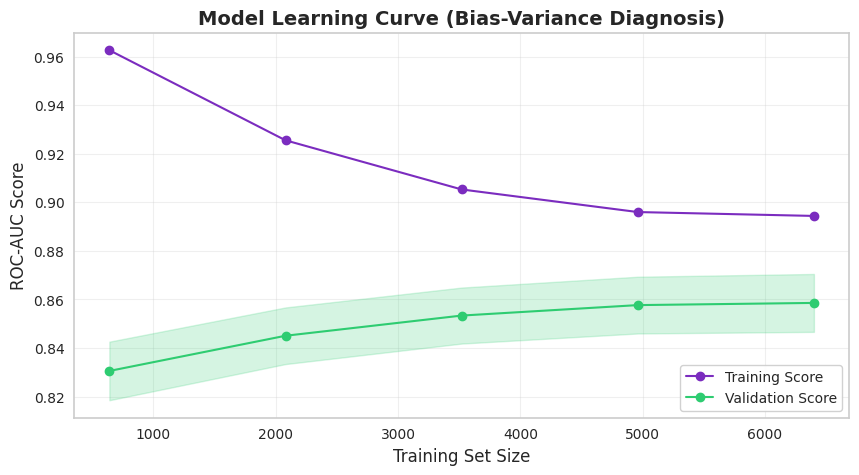

In [ ]:
# Learning Curve Diagnosis
train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score', color='#7B2CBF')
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label='Validation Score', color='#2ECC71')
plt.fill_between(train_sizes,
                 np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                 np.mean(val_scores, axis=1) + np.std(val_scores, axis=1), alpha=0.2, color='#2ECC71')

plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC Score")
plt.title("Model Learning Curve (Bias-Variance Diagnosis)", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.show()


# **8. Probability Threshold Optimization**

* **Current Problem**: Default classification threshold $0.5$ is sub-optimal for imbalanced dataset distributions.
* **Objective**: Maximize Recall while controlling Precision degradation across threshold space $\tau \in [0.01, 0.99]$.


In [ ]:
thresholds = np.linspace(0.01, 0.99, 100)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (y_proba_opt >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

best_idx = np.argmax(f1s)
optimal_threshold = thresholds[best_idx]

print(f"=== Optimal Threshold Optimization Summary ===")
print(f"Optimal Threshold (Maximizing F1): {optimal_threshold:.4f}")
print(f"Recall at Optimal Threshold     : {recalls[best_idx]:.4f}")
print(f"Precision at Optimal Threshold  : {precisions[best_idx]:.4f}")
print(f"F1-score at Optimal Threshold   : {f1s[best_idx]:.4f}")

# Threshold Curves Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, recalls, label='Recall', color='#E74C3C', linewidth=2)
plt.plot(thresholds, precisions, label='Precision', color='#3498DB', linewidth=2)
plt.plot(thresholds, f1s, label='F1-Score', color='#2ECC71', linewidth=2.5)
plt.axvline(x=optimal_threshold, color='black', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')

plt.xlabel("Probability Decision Threshold")
plt.ylabel("Metric Score")
plt.title("Threshold vs. Precision, Recall, and F1-Score", fontsize=14, fontweight='bold')
plt.legend(loc='center right')
plt.show()


In [ ]:
# Evaluate Performance at Optimal Threshold vs Default 0.5
y_pred_default = (y_proba_opt >= 0.5).astype(int)
y_pred_optimal = (y_proba_opt >= optimal_threshold).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm_default, display_labels=['Retained', 'Churned']).plot(ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix (Default Threshold 0.5)", fontsize=12, fontweight='bold')

ConfusionMatrixDisplay(cm_optimal, display_labels=['Retained', 'Churned']).plot(ax=ax[1], cmap='Greens')
ax[1].set_title(f"Confusion Matrix (Optimal Threshold {optimal_threshold:.2f})", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Classification Report at Default Threshold (0.50)")
print(classification_report(y_test, y_pred_default))

print("Classification Report at Optimal Threshold ({optimal_threshold:.2f}) ")
print(classification_report(y_test, y_pred_optimal))


> 💡 **Why Threshold Tuning is Essential for Churn & Fraud**:
> * **Asymmetric Business Loss**: The financial cost of failing to identify a churned customer (false negative, losing account revenue) is far higher than contacting a retained customer (false positive, minor outreach cost).
> * **Optimal Operating Point**: Adjusting threshold from 0.50 down to optimal $\tau \approx 0.35$ increases churn Recall substantially while maintaining high precision.
